In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import requests
from pathlib import Path
from PIL import Image
from pkg_resources import packaging
from collections import Counter
from itertools import combinations
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms

/tmp/ipykernel_58/3983547996.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [3]:
def explode_df(df, col):
    df = df.explode(col).reset_index(drop=True)
    df = df.merge(pd.json_normalize(df[col]), left_index=True, right_index=True).drop(col, axis=1)
    return df

In [4]:
os.listdir('/kaggle/input/datasets/nqa112/vizwiz-2023-edition/Annotations')

['train.json', 'test.json', 'val.json']

In [5]:
train_test = pd.read_json("/kaggle/input/datasets/nqa112/vizwiz-2023-edition/Annotations/train.json", orient="records")
val = pd.read_json("/kaggle/input/datasets/nqa112/vizwiz-2023-edition/Annotations/val.json", orient="records")

In [6]:
train_test['answerable_answer_type'] = (
    train_test['answerable'].astype(str)
    + "_"
    + train_test['answer_type'].astype(str)
)

train, test = train_test_split(
    train_test,
    test_size=0.05,
    random_state=42,
    stratify=train_test['answerable_answer_type']
)

# Remove helper column
train = train.drop(columns=['answerable_answer_type'])
test = test.drop(columns=['answerable_answer_type'])

In [7]:
print(train.columns.tolist())
print(test.columns.tolist())

['image', 'question', 'answers', 'answer_type', 'answerable']
['image', 'question', 'answers', 'answer_type', 'answerable']


In [8]:
df = pd.concat([train, test, val])
df.reset_index(drop=True, inplace=True)
df

,image,question,answers,answer_type,answerable
0,VizWiz_train_00011239.jpg,What is this in the jar?,"[{'answer': 'empty', 'answer_confidence': 'may...",other,1
1,VizWiz_train_00016611.jpg,Tell me what you see in this photograph.,"[{'answer_confidence': 'yes', 'answer': 'bar'}...",other,1
2,VizWiz_train_00014090.jpg,"What is in this package, what kind of cake mix?","[{'answer_confidence': 'maybe', 'answer': 'una...",unanswerable,0
3,VizWiz_train_00010034.jpg,What is this?,"[{'answer_confidence': 'yes', 'answer': 'remot...",other,1
4,VizWiz_train_00014362.jpg,What do you see?,"[{'answer_confidence': 'yes', 'answer': 'unans...",unanswerable,0
...,...,...,...,...,...
24837,VizWiz_val_00004314.jpg,what is this?,"[{'answer_confidence': 'yes', 'answer': 'salad...",other,1
24838,VizWiz_val_00004315.jpg,Is this modern?,"[{'answer_confidence': 'maybe', 'answer': 'una...",unanswerable,0
24839,VizWiz_val_00004316.jpg,I need to buy this battery for my cordless pho...,"[{'answer_confidence': 'yes', 'answer': 'unans...",unanswerable,0
24840,VizWiz_val_00004317.jpg,What kind of mix is this?,"[{'answer_confidence': 'maybe', 'answer': 'cak...",other,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24842 entries, 0 to 24841
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image        24842 non-null  object
 1   question     24842 non-null  object
 2   answers      24842 non-null  object
 3   answer_type  24842 non-null  object
 4   answerable   24842 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 970.5+ KB


In [10]:
df['answerable_answer_type'] = df['answerable'].astype(str) + "_" + df['answer_type'].astype(str)

In [11]:
explode_df(val, 'answers')

,image,question,answer_type,answerable,answer,answer_confidence
0,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,unanswerable,0,unanswerable,yes
1,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,unanswerable,0,unanswerable,yes
2,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,unanswerable,0,unanswerable,yes
3,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,unanswerable,0,unanswerable,yes
4,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,unanswerable,0,unanswerable,maybe
...,...,...,...,...,...,...
43185,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,masala,maybe
43186,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,unanswerable,yes
43187,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,garam marsala,yes
43188,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,masala,maybe


In [12]:
df3 = explode_df(df, 'answers')
df3.drop(columns=['answerable_answer_type'])

,image,question,answer_type,answerable,answer,answer_confidence
0,VizWiz_train_00011239.jpg,What is this in the jar?,other,1,empty,maybe
1,VizWiz_train_00011239.jpg,What is this in the jar?,other,1,yogurt,yes
2,VizWiz_train_00011239.jpg,What is this in the jar?,other,1,empty,yes
3,VizWiz_train_00011239.jpg,What is this in the jar?,other,1,water,maybe
4,VizWiz_train_00011239.jpg,What is this in the jar?,other,1,nothing,yes
...,...,...,...,...,...,...
248415,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,masala,maybe
248416,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,unanswerable,yes
248417,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,garam marsala,yes
248418,VizWiz_val_00004318.jpg,What kind of spice is this?,other,1,masala,maybe


In [13]:
df3['answer_confidence'].value_counts(normalize=True)

answer_confidence
yes      0.765804
maybe    0.157045
no       0.077152
Name: proportion, dtype: float64

In [14]:
train_eda = explode_df(train, 'answers')
train_eda['answer'].value_counts(normalize=True)

answer
unanswerable                    0.272835
no                              0.025851
yes                             0.022143
white                           0.012126
grey                            0.010818
                                  ...   
cherry apple                    0.000005
cranberry apple juice           0.000005
some oats food                  0.000005
training toilet                 0.000005
chili 2 cans vegetarian bean    0.000005
Name: proportion, Length: 39435, dtype: float64

In [15]:
val_eda = explode_df(val, 'answers')
val_eda['answer'].value_counts(normalize=True)

answer
unanswerable        0.316856
no                  0.029961
yes                 0.021510
white               0.011878
blue                0.008451
                      ...   
library books       0.000023
dear parents        0.000023
poor                0.000023
sony game           0.000023
perfect partners    0.000023
Name: proportion, Length: 10903, dtype: float64

In [16]:
test_eda = explode_df(test, 'answers')
test_eda['answer'].value_counts(normalize=True)

answer
unanswerable                                     0.272736
yes                                              0.023564
no                                               0.022493
white                                            0.012269
grey                                             0.010419
                                                   ...   
this klondike choco taco peanut butter flavor    0.000097
ice cream dessert                                0.000097
dinner setting                                   0.000097
place setting                                    0.000097
black square                                     0.000097
Name: proportion, Length: 3107, dtype: float64

In [17]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

# Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

cuda:0
Tesla T4


In [18]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-7n5jsj8o
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-7n5jsj8o
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369547 sha256=2dd72e0420c4a5f19ef7be332df209a876568cb8927b688b3d0989be34903793
  Stored in directory: /tmp/pip-ephem-wheel-cache-w7gris44/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [19]:
import clip 
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [20]:
clip_model, preprocess = clip.load("RN50", device=device)

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in clip_model.parameters()]):,}")
print(f"Input resolution: {clip_model.visual.input_resolution}")
print(f"Context length: {clip_model.context_length}")
print(f"Vocab size: {clip_model.vocab_size}")

100%|████████████████████████████████████████| 244M/244M [00:01<00:00, 193MiB/s]


Model parameters: 102,007,137
Input resolution: 224
Context length: 77
Vocab size: 49408


In [21]:
class VizWizDataset(Dataset):
    def __init__(self, df, base_path, transform=None):
        self.df = df.copy()
        self.n_samples = df.shape[0]
        self.image_path = self.df["image"].apply(lambda row: str(Path(base_path) / row))
        
        def most_common(lst):
            data = Counter(lst)
            return max(lst, key=data.get)
        
        self.df['max_answer'] = self.df["answers"].apply(lambda row: most_common([ans["answer"] for ans in row]))
        self.transform = transform
        
        self.X = torch.empty((len(self.df), 2048), dtype=torch.float32)
        for i in range(len(self.df)):
            image = Image.open(self.image_path.iloc[i]).convert('RGB')
            if self.transform is not None:
                image = self.transform(image).unsqueeze(0).to(device)
                
            question = clip.tokenize(self.df['question'].iloc[i]).to(device)
            with torch.no_grad():
                image_features = clip_model.encode_image(image)
                text_features = clip_model.encode_text(question)
            self.X[i] = torch.cat((image_features, text_features), 1).to(torch.float32)
                
    def __getitem__(self, index):
        return index, self.X[index], self.df['max_answer'].iloc[index], self.df['answerable'].iloc[index]
        
    def __len__(self):
        return self.n_samples

In [22]:
train_dataset_path = '/kaggle/input/datasets/nqa112/vizwiz-2023-edition/train/train'
val_dataset_path = '/kaggle/input/datasets/nqa112/vizwiz-2023-edition/val/val'
test_dataset_path = '/kaggle/input/datasets/nqa112/vizwiz-2023-edition/test/test'

In [23]:
if not os.path.exists('/kaggle/working/train_dataset.pth'):
    train_dataset = VizWizDataset(train, base_path=train_dataset_path, transform=preprocess)
    torch.save(train_dataset, '/kaggle/working/train_dataset.pth')

In [24]:
if not os.path.exists('/kaggle/working/val_dataset.pth'):
    val_dataset = VizWizDataset(val, base_path=val_dataset_path, transform=preprocess)
    torch.save(val_dataset, '/kaggle/working/val_dataset.pth')

In [25]:
if not os.path.exists('/kaggle/working/test_dataset.pth'):
    test_dataset = VizWizDataset(test, base_path=train_dataset_path, transform=preprocess)
    torch.save(test_dataset, '/kaggle/working/test_dataset.pth')

In [26]:
ANSWER_CANDIDATES = train_dataset.df['max_answer'].nunique()

In [27]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=ANSWER_CANDIDATES)
enc.fit(np.array(train_dataset.df['max_answer']).reshape(-1, 1))

OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=5227)

In [28]:
BATCH_SIZE = 32

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
class VQAModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(VQAModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.dropout1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.ln2 = nn.LayerNorm(output_dim)
        self.dropout2 = nn.Dropout(p=0.5)

    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.ln2(x)
        x = self.dropout2(x)
        return x

In [30]:
def accuracy_vqa(df, index, value):
    if value == None:
        return 0
    ans_list = [elem['answer'] for elem in df.iloc[index]['answers']]
    return np.divide(np.sum(np.minimum(np.count_nonzero(np.array(list(combinations(ans_list, 9))) == value, axis=1), 1)), 10)

In [31]:
def train_vqa(model, data_loader, criterion, optimizer):
    model.train()
    train_loss = 0
    accuracy = 0
    for i, (index, x, answers, _) in enumerate(data_loader):
        x = x.to(device) 
        answers = torch.as_tensor(enc.transform(np.array(answers).reshape(-1, 1)).astype(int)).to(device).squeeze(1)
        
        # Forward Pass
        outputs = model(x).squeeze(1)
        loss = criterion(outputs, answers)
        
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        
        # Update Weights
        optimizer.step()
        
         # Loss and Accuracy Calculations
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        predicted = enc.inverse_transform(np.array(predicted.to('cpu')).reshape(-1,1))
        for ip, idx in enumerate(index):
            accuracy += accuracy_vqa(data_loader.dataset.df, int(idx), predicted[ip])

    train_loss /= len(data_loader.dataset)
    accuracy /= len(data_loader.dataset)
    
    return train_loss, accuracy

In [32]:
def validate_vqa(model, data_loader, criterion):
    model.eval()
    val_loss = 0
    accuracy = 0
    with torch.no_grad():
        for i, (index, x, answers, _) in enumerate(data_loader):
            x = x.to(device)
            answers = torch.as_tensor(enc.transform(np.array(answers).reshape(-1, 1)).astype(int)).to(device).squeeze(1)
            
            # Forward Pass
            outputs = model(x).squeeze(1)
            loss = criterion(outputs, answers)
            
            # Loss and Accuracy Calculations
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            predicted = enc.inverse_transform(np.array(predicted.to('cpu')).reshape(-1,1))
            for ip, idx in enumerate(index):
                accuracy += accuracy_vqa(data_loader.dataset.df, int(idx), predicted[ip])
                
    val_loss /= len(data_loader.dataset)
    accuracy /= len(data_loader.dataset)

    return val_loss, accuracy   

In [33]:
NUM_EPOCHS = 30
LEARNING_RATE = 0.0001

In [34]:
input_dim = 2048
hidden_dim = 2048
output_dim = ANSWER_CANDIDATES + 1

model_vqa = VQAModel(input_dim, hidden_dim, output_dim).to(device)

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_vqa.parameters(), lr=LEARNING_RATE)

In [36]:
lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4)

In [41]:
VQA_MODEL_NAME = 'vqa_model.pth'
checkpoint_dir = '/kaggle/working/checkpoints'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)
    
# Define the variables for saving the best checkpoint
best_val_loss = float('inf')
patience = 10

In [42]:
# Defining Lists to store training and validation accuracies and losses
train_vqa_acc_history = []
train_vqa_loss_history = []
val_vqa_acc_history = []
val_vqa_loss_history = []

counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]:")
    start_time = time.perf_counter()
    
    train_loss, train_acc = train_vqa(model_vqa, train_loader, criterion, optimizer)
    val_loss, val_acc = validate_vqa(model_vqa, val_loader, criterion)
    
    epoch_time = time.perf_counter() - start_time
    avg_step_time = epoch_time / (len(train_loader) + len(val_loader))
    
    train_vqa_acc_history.append(train_acc)
    train_vqa_loss_history.append(train_loss)
    val_vqa_acc_history.append(val_acc)
    val_vqa_loss_history.append(val_loss)
    
     # Check if the validation loss has improved
    if val_loss < best_val_loss:
        print(f"val_loss improved from {best_val_loss:.5f} to {val_loss:.5f}, saving model to {VQA_MODEL_NAME}")
        best_val_loss = val_loss
        counter = 0
        # Save the model checkpoint
        checkpoint_path_vqa = os.path.join(checkpoint_dir, VQA_MODEL_NAME)
        torch.save(model_vqa, checkpoint_path_vqa)
    else:
        counter += 1
        if counter >= patience:
            print(f"val_loss hasn't improved for {patience} epochs. Early stopping.")
            break
    
    print(f"{int(np.round(epoch_time))}s {avg_step_time*1e3:.4f}ms/step - loss: {train_loss:.4f} - accuracy: {train_acc*100:.4f}% - val_loss: {val_loss:.4f} - val_accuracy: {val_acc*100:.4f}% - lr: {optimizer.param_groups[0]['lr']}")
    
    
    lr_scheduler.step(val_loss)
    print()

Epoch [1/30]:
val_loss improved from inf to 0.24312, saving model to vqa_model.pth
13s 18.0498ms/step - loss: 0.1828 - accuracy: 41.5295% - val_loss: 0.2431 - val_accuracy: 67.4369% - lr: 1e-05

Epoch [2/30]:
val_loss improved from 0.24312 to 0.24295, saving model to vqa_model.pth
14s 18.2435ms/step - loss: 0.1805 - accuracy: 41.9240% - val_loss: 0.2430 - val_accuracy: 67.5179% - lr: 1.0000000000000002e-06

Epoch [3/30]:
val_loss improved from 0.24295 to 0.24267, saving model to vqa_model.pth
14s 18.2798ms/step - loss: 0.1801 - accuracy: 42.2953% - val_loss: 0.2427 - val_accuracy: 67.4948% - lr: 1.0000000000000002e-06

Epoch [4/30]:
14s 18.3795ms/step - loss: 0.1820 - accuracy: 41.8250% - val_loss: 0.2428 - val_accuracy: 67.4531% - lr: 1.0000000000000002e-06

Epoch [5/30]:
14s 18.2621ms/step - loss: 0.1800 - accuracy: 42.7919% - val_loss: 0.2427 - val_accuracy: 67.4971% - lr: 1.0000000000000002e-06

Epoch [6/30]:
14s 18.2254ms/step - loss: 0.1821 - accuracy: 42.2682% - val_loss: 0.2430

In [48]:
# No need to re-initialize the architecture first
model_vqa = torch.load(checkpoint_path_vqa, weights_only=False)
model_vqa = model_vqa.to(device)
model_vqa.eval()

VQAModel(
  (fc1): Linear(in_features=2048, out_features=2048, bias=True)
  (ln1): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=2048, out_features=5228, bias=True)
  (ln2): LayerNorm((5228,), eps=1e-05, elementwise_affine=True)
  (dropout2): Dropout(p=0.5, inplace=False)
)

In [49]:
train_loss_vqa, train_acc_vqa = validate_vqa(model_vqa, train_loader, criterion)
print(f"Training Loss: {train_loss_vqa:.4f}")
print(f"Training Accuracy: {train_acc_vqa*100:.4f}%")

Training Loss: 0.1465
Training Accuracy: 70.3457%


In [50]:
val_loss_vqa, val_acc_vqa = validate_vqa(model_vqa, val_loader, criterion)
print(f"Validation Loss: {val_loss_vqa:.4f}")
print(f"Validation Accuracy: {val_acc_vqa*100:.4f}%")

Validation Loss: 0.2427
Validation Accuracy: 67.4948%


In [51]:
test_loss_vqa, test_acc_vqa = validate_vqa(model_vqa, test_loader, criterion)
print(f"Test Loss: {test_loss_vqa:.4f}")
print(f"Test Accuracy: {test_acc_vqa*100:.4f}%")

Test Loss: 0.2710
Test Accuracy: 61.6650%


In [52]:
class AnsModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(AnsModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(p=0.5)
        self.activation = nn.SiLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [53]:
def train_ans(model, data_loader, criterion, optimizer):
    model.train()
    train_loss = 0
    train_scores = []
    train_targets = []

    for i, (_, x, _, targets) in enumerate(data_loader):
        x = x.to(device)
        targets = targets.to(device)
        
        # Forward Pass
        outputs = model(x).squeeze(1)
        loss = criterion(outputs, targets.float())
        
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        
        # Update Weights
        optimizer.step()
        
         # Loss and Accuracy Calculations
        train_loss += loss.item()
        train_scores.append(outputs.detach().cpu().numpy())
        train_targets.append(targets.cpu().numpy())
    
    train_loss /= len(data_loader.dataset)
    
    train_targets = np.concatenate(train_targets)
    train_scores = np.concatenate(train_scores)
    accuracy = average_precision_score(train_targets, train_scores)
    
    return train_loss, accuracy

In [54]:
def validate_ans(model, data_loader, criterion):
    model.eval()
    val_loss = 0
    val_scores = []
    val_targets = []
    
    with torch.no_grad():
        for i, (_, x, _, targets) in enumerate(data_loader):
            x = x.to(device)
            targets = targets.to(device)
            
            # Forward Pass
            outputs = model(x).squeeze(1)
            loss = criterion(outputs, targets.float())
            
            # Loss and Accuracy Calculations
            val_loss += loss.item()
            val_scores.append(outputs.cpu().numpy())
            val_targets.append(targets.cpu().numpy()) 
            
            
    val_loss /= len(data_loader.dataset)
    
    val_targets = np.concatenate(val_targets)
    val_scores = np.concatenate(val_scores)
    accuracy = average_precision_score(val_targets, val_scores)

    return val_loss, accuracy  

In [55]:
NUM_EPOCHS = 30
LEARNING_RATE = 0.0001

In [56]:
input_dim = 2048
hidden_dim = 2048
output_dim = 1

model_ans = AnsModel(input_dim, hidden_dim, output_dim).to(device)

In [57]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_ans.parameters(), lr=LEARNING_RATE)

In [59]:
lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4)

In [60]:
ANS_MODEL_NAME = 'ans_model.pth'
checkpoint_dir = '/kaggle/working/checkpoints'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)
    
# Define the variables for saving the best checkpoint
best_val_loss = float('inf')
patience = 10

In [61]:
# Defining Lists to store training and validation accuracies and losses
train_ans_acc_history = []
train_ans_loss_history = []
val_ans_acc_history = []
val_ans_loss_history = []

counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]:")
    start_time = time.perf_counter()
    
    train_loss, train_acc = train_ans(model_ans, train_loader, criterion, optimizer)
    val_loss, val_acc = validate_ans(model_ans, val_loader, criterion)
    
    epoch_time = time.perf_counter() - start_time
    avg_step_time = epoch_time / (len(train_loader) + len(val_loader))
    
    train_ans_acc_history.append(train_acc)
    train_ans_loss_history.append(train_loss)
    val_ans_acc_history.append(val_acc)
    val_ans_loss_history.append(val_loss)
    
     # Check if the validation loss has improved
    if val_loss < best_val_loss:
        print(f"val_loss improved from {best_val_loss:.5f} to {val_loss:.5f}, saving model to {ANS_MODEL_NAME}")
        best_val_loss = val_loss
        counter = 0
        # Save the model checkpoint
        checkpoint_path_ans = os.path.join(checkpoint_dir, ANS_MODEL_NAME)
        torch.save(model_ans, checkpoint_path_ans)
    else:
        counter += 1
        if counter >= patience:
            print(f"val_loss hasn't improved for {patience} epochs. Early stopping.")
            break
            
    print(f"{int(np.round(epoch_time))}s {avg_step_time*1e3:.4f}ms/step - loss: {train_loss:.4f} - accuracy: {train_acc*100:.4f}% - val_loss: {val_loss:.4f} - val_accuracy: {val_acc*100:.4f}% - lr: {optimizer.param_groups[0]['lr']}")
    
    lr_scheduler.step(val_loss)
    print()        

Epoch [1/30]:
val_loss improved from inf to 0.01330, saving model to ans_model.pth
2s 3.2892ms/step - loss: 0.0136 - accuracy: 92.5373% - val_loss: 0.0133 - val_accuracy: 93.1296% - lr: 0.0001

Epoch [2/30]:
val_loss improved from 0.01330 to 0.01320, saving model to ans_model.pth
2s 3.1552ms/step - loss: 0.0121 - accuracy: 94.5287% - val_loss: 0.0132 - val_accuracy: 93.6128% - lr: 0.0001

Epoch [3/30]:
val_loss improved from 0.01320 to 0.01265, saving model to ans_model.pth
2s 3.0774ms/step - loss: 0.0115 - accuracy: 95.2341% - val_loss: 0.0127 - val_accuracy: 93.9848% - lr: 0.0001

Epoch [4/30]:
2s 3.0326ms/step - loss: 0.0109 - accuracy: 95.7685% - val_loss: 0.0135 - val_accuracy: 94.1675% - lr: 0.0001

Epoch [5/30]:
val_loss improved from 0.01265 to 0.01254, saving model to ans_model.pth
2s 3.0207ms/step - loss: 0.0102 - accuracy: 96.4419% - val_loss: 0.0125 - val_accuracy: 94.0385% - lr: 0.0001

Epoch [6/30]:
val_loss improved from 0.01254 to 0.01246, saving model to ans_model.pth


In [63]:
model_ans = torch.load(checkpoint_path_ans, weights_only=False)
model_ans = model_ans.to(device) # Optional: Send to GPU if you are using one
model_ans.eval()

AnsModel(
  (fc1): Linear(in_features=2048, out_features=2048, bias=True)
  (norm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (activation): SiLU()
  (fc2): Linear(in_features=2048, out_features=1, bias=True)
)

In [64]:
train_loss_ans, train_acc_ans = validate_ans(model_ans, train_loader, criterion)
print(f"Training Loss: {train_loss_ans:.4f}")
print(f"Training Accuracy: {train_acc_ans*100:.4f}%")

Training Loss: 0.0083
Training Accuracy: 97.8861%


In [65]:
val_loss_ans, val_acc_ans = validate_ans(model_ans, val_loader, criterion)
print(f"Validation Loss: {val_loss_ans:.4f}")
print(f"Validation Accuracy: {val_acc_ans*100:.4f}%")

Validation Loss: 0.0122
Validation Accuracy: 94.4638%


In [66]:
test_loss_ans, test_acc_ans = validate_ans(model_ans, test_loader, criterion)
print(f"Test Loss: {test_loss_ans:.4f}")
print(f"Test Accuracy: {test_acc_ans*100:.4f}%")

Test Loss: 0.0117
Test Accuracy: 95.5119%


In [67]:
def test_single_example(image, question, clip_model, model_vqa, model_ans, encoder):
    image = preprocess(image).unsqueeze(0).to(device)
    question = clip.tokenize(question).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image)
        text_features = clip_model.encode_text(question)
    x = torch.cat((image_features, text_features), 1).to(torch.float32)
    
    # Visual Question Answering
    outputs_vqa = model_vqa(x).squeeze(1)
    _, predicted = outputs_vqa.max(1)
    answer = encoder.inverse_transform(np.array(predicted.to('cpu')).reshape(-1,1))
    
    # Answerability
    answerability_score = F.sigmoid(model_ans(x).squeeze(1))
    
    return answer, answerability_score

Answer: yes
Answerability Confidence: 99.139%



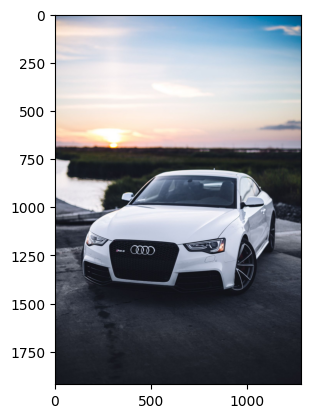

In [86]:
url = "https://i.pinimg.com/originals/13/9e/48/139e48f39ada07c430b33ec2f671aa33.jpg"
img = Image.open(BytesIO(requests.get(url).content)).convert('RGB')
plt.imshow(img)
question = "is there sunse?"

answer, answerability_score = test_single_example(img, question, clip_model, model_vqa, model_ans, enc)
print(f"Answer: {answer.item()}")
print(f"Answerability Confidence: {answerability_score.item()*100:.3f}%\n")

Answer: no
Answerability Confidence: 94.952%



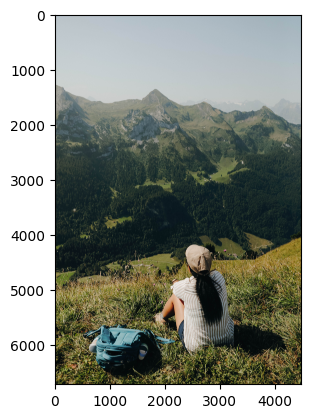

In [70]:
url2 = "https://images.pexels.com/photos/39557160/pexels-photo-39557160.jpeg"
img2 = Image.open(BytesIO(requests.get(url2).content)).convert('RGB')
plt.imshow(img2)
question2 = "is there a car?"

answer2, answerability_score2 = test_single_example(img2, question2, clip_model, model_vqa, model_ans, enc)
print(f"Answer: {answer2.item()}")
print(f"Answerability Confidence: {answerability_score2.item()*100:.3f}%\n")

Answer: yes
Answerability Confidence: 92.416%



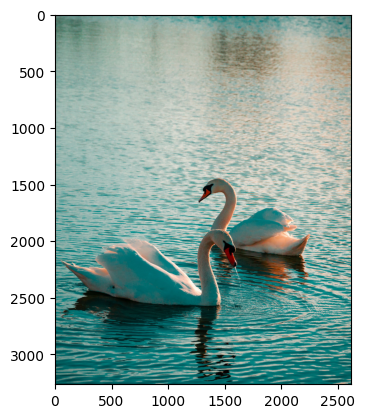

In [84]:
url3 = "https://images.pexels.com/photos/16283239/pexels-photo-16283239.jpeg"
img3 = Image.open(BytesIO(requests.get(url3).content)).convert('RGB')
plt.imshow(img3)
question3 = "is there any water?"

answer3, answerability_score3 = test_single_example(img3, question3, clip_model, model_vqa, model_ans, enc)
print(f"Answer: {answer3.item()}")
print(f"Answerability Confidence: {answerability_score3.item()*100:.3f}%\n")